# Phishing URL Classification: Data Preparation, Model Development, and Evaluation

This notebook presents the project's workflow, from data cleaning and initial model comparisons to hyperparameter tuning, error analysis, and ethical considerations. The observations explain the saved results and their implications for phishing detection.

## Environment Setup


In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Locate this project's root whether VS Code starts in notebooks/ or the root.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/config.py").is_file()
             and (p / "data/PhiUSIIL_Phishing_URL_Dataset.csv").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook within the project containing src/ and data/.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src import config as C
from src.data import load_data
from src.splits import make_split, get_xy
from src.models import build_models
print("Project:", ROOT)

from src.notebook_analysis import (load_and_summarize, plot_distributions, prepare_split,
    quality_diagnostics, review_saved_metrics, phishing_summary, train_initial_model)


Project: C:\Users\alber\Groupe_Project_1_phdai_732_gp_phiusil


## 1. Introduction and Problem Framing
### Classification Objective

The objective is to distinguish phishing URLs from legitimate URLs using the PhiUSIIL dataset. In this dataset, **0 represents phishing** and **1 represents legitimate traffic**. Precision, recall, and F1 are reported with phishing as the positive class.

The analysis compares three feature sets: `full`, `no_derived`, and `url_only`. The URL-only configuration uses 18 numerical features available from the URL itself, making it relevant to screening links before retrieving page content. Performance is assessed through classification metrics, missed phishing URLs, and false alarms on legitimate URLs.


In [2]:
# Inspect the target, feature configurations, and experiment settings.
print("Target:", C.LABEL)
print("Classes:", {0: "Phishing", 1: "Legitimate"})
display(pd.DataFrame([
    {"feature_set": name, "predictors": len(columns)}
    for name, columns in C.FEATURE_SETS.items()
]))
print("Seed:", C.SEED, "| Test fraction:", C.TEST_SIZE)


Target: label
Classes: {0: 'Phishing', 1: 'Legitimate'}


,feature_set,predictors
0,full,50
1,no_derived,44
2,url_only,18


Seed: 42 | Test fraction: 0.25


## 2. Dataset Exploration and Preprocessing
### Load and Validate the Dataset

The following cell loads the dataset, removes duplicate URLs, and checks that the cleaned data match the recorded dataset fingerprint. The summary provides an initial view of the dataset's size, numerical features, and missing values.


In [3]:
df, cleaning_log = load_and_summarize()


,Value
rows_raw,235795
cols_raw,56
duplicate_urls_removed,425
rows_clean,235370
n_unique_domains,220086
fingerprint_matches,True


,count,mean,std,min,25%,50%,75%,max
URLLength,235370.0,34.545516,41.332730,13.0,23.000,27.000,34.000,6097.000
DomainLength,235370.0,21.456022,9.127733,4.0,16.000,20.000,24.000,110.000
IsDomainIP,235370.0,0.002702,0.051912,0.0,0.000,0.000,0.000,1.000
TLDLength,235370.0,2.764269,0.599667,2.0,2.000,3.000,3.000,13.000
NoOfSubDomain,235370.0,1.164957,0.600695,0.0,1.000,1.000,1.000,10.000
HasObfuscation,235370.0,0.002052,0.045254,0.0,0.000,0.000,0.000,1.000
NoOfObfuscatedChar,235370.0,0.024880,1.877922,0.0,0.000,0.000,0.000,447.000
ObfuscationRatio,235370.0,0.000138,0.003818,0.0,0.000,0.000,0.000,0.348
NoOfLettersInURL,235370.0,19.405600,29.099537,0.0,10.000,14.000,20.000,5191.000
LetterRatioInURL,235370.0,0.515749,0.123234,0.0,0.435,0.519,0.594,0.926


Missing values: {}


### Examine Class Balance and URL Length

The plots show the relative frequency of phishing and legitimate URLs and the distribution of URL lengths. These checks help describe the data before fitting any models and provide context for interpreting accuracy and the majority-class baseline.


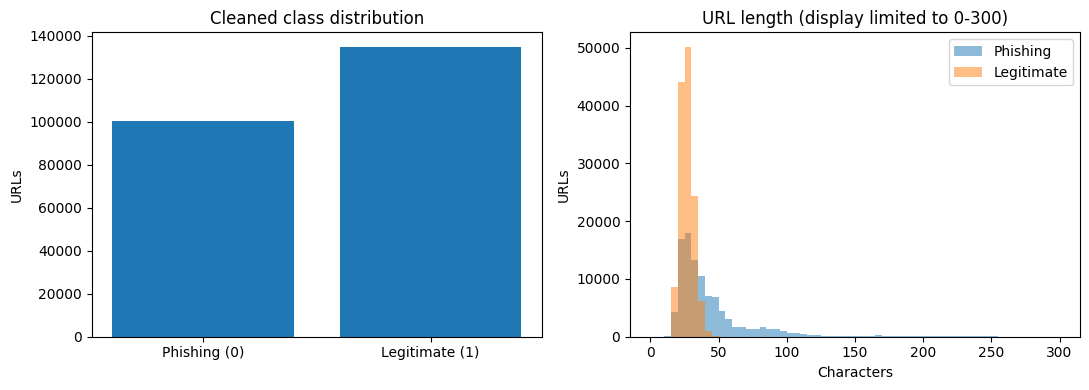

In [4]:
plot_distributions(df)


### Reuse the Saved Training and Test Split

The saved split assigns 75% of the cleaned observations to training and 25% to testing. Reusing these assignments keeps the initial model and tuning comparisons consistent.


In [5]:
assignment, X_train, X_test, y_train, y_test = prepare_split(df)


Training: 176,527; testing: 58,843
URL-only predictors: 18
Recorded domains shared across partitions: 2318


**Observations:**

- The cleaned dataset is divided into 176,527 training observations and 58,843 test observations, with 18 predictors in the URL-only configuration.
- Although the observations are separated, 2,318 recorded domains appear in both partitions. Different URLs from the same domain can therefore occur in training and testing.
- This overlap limits what the row-level split can demonstrate about unfamiliar domains. Section 5 includes an additional evaluation in which the recorded domains do not overlap between training and testing.


### Check Data Quality and Training Distributions

The diagnostics examine missing values, non-finite values, feature types, and the range of values in the training partition. This provides a basis for deciding which preprocessing steps are necessary.


In [6]:
quality_diagnostics(df, assignment)


,dtype,missing,unique_train,non_finite
URLLength,int64,0,456,0
DomainLength,int64,0,100,0
IsDomainIP,int64,0,2,0
TLDLength,int64,0,11,0
NoOfSubDomain,int64,0,10,0
HasObfuscation,int64,0,2,0
NoOfObfuscatedChar,int64,0,20,0
ObfuscationRatio,float64,0,134,0
NoOfLettersInURL,int64,0,396,0
LetterRatioInURL,float64,0,695,0


,count,mean,std,min,1%,50%,95%,99%,max
URLLength,176527.0,34.599217,41.048668,13.000000,17.000000,27.000000,74.000000,146.740000,5.794000e+03
DomainLength,176527.0,21.450911,9.133470,4.000000,8.000000,20.000000,38.000000,57.000000,1.100000e+02
IsDomainIP,176527.0,0.002730,0.052183,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00
TLDLength,176527.0,2.764790,0.599894,2.000000,2.000000,3.000000,3.000000,4.000000,1.300000e+01
NoOfSubDomain,176527.0,1.164456,0.600648,0.000000,0.000000,1.000000,2.000000,3.000000,1.000000e+01
HasObfuscation,176527.0,0.002090,0.045672,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00
NoOfObfuscatedChar,176527.0,0.028653,2.156206,0.000000,0.000000,0.000000,0.000000,0.000000,4.470000e+02
ObfuscationRatio,176527.0,0.000148,0.004044,0.000000,0.000000,0.000000,0.000000,0.000000,3.480000e-01
NoOfLettersInURL,176527.0,19.434579,27.483009,0.000000,4.000000,14.000000,50.000000,100.000000,4.992000e+03
LetterRatioInURL,176527.0,0.515798,0.123366,0.000000,0.231000,0.519000,0.731000,0.786000,9.260000e-01


label,phishing_share,legitimate_share
split,,
test,0.427069,0.572931
train,0.427073,0.572927


Constant training predictors: []


### Apply Preprocessing and Verify Scaling

The shared preprocessing routine saves the cleaned dataset and checks all three feature configurations. Scaling is fitted using training observations, and the logistic regression pipeline fits its scaler separately within each cross-validation training fold.


In [7]:
from src.preprocessing import run_preprocessing, show_preprocessing_results

# Shared loader, original row identities, existing split, and training-only scaling.
# Save cleaned data and preprocessing diagnostics using the project module.
preprocessing_summary = run_preprocessing()
preprocessing_results = show_preprocessing_results()


,Verified result
rows_raw,235795
rows_clean,235370
duplicate_urls_removed,425
missing_values,0
non_finite_model_values,0
fingerprint_matches,True


,feature_set,n_features,n_train,n_test,scaled_inputs_finite
0,full,50,176527,58843,True
1,no_derived,44,176527,58843,True
2,url_only,18,176527,58843,True


,split,phishing,legitimate
0,test,25130,33713
1,train,75390,101137


Cleaned dataset: data\PhiUSIIL_cleaned.csv
Fitted on training rows only; model pipelines refit within each CV fold.


**Observations:**

- Removing 425 duplicate URLs reduces the dataset from 235,795 to 235,370 observations. The cleaned dataset matches the recorded fingerprint.
- The checks find no missing values or non-finite values in the configured model inputs. Because these inputs are numerical, this workflow does not require imputation or categorical encoding.
- The `full`, `no_derived`, and `url_only` feature sets contain 50, 44, and 18 predictors, respectively. Each uses the same saved training and test assignments.
- Some numerical features have wide ranges. These extreme values are retained, while the logistic regression pipeline uses standardization to account for differences in feature scale.
- Fitting preprocessing steps on training data, including within cross-validation folds, prevents validation and test observations from influencing the fitted scaling parameters.


## 3. Initial Model Development
### Define the Initial Models

The initial comparison includes a majority-class baseline, logistic regression, a decision tree, and a random forest. Each model is evaluated with all three feature sets so that differences in model choice and available information can be examined separately.


In [8]:
# 3. Initial Model Development
# Use the project's shared model roster, feature sets, and frozen split.
from src import config as C
from src.models import build_models
from src.initial_models import run_initial_models, show_initial_results
from src.notebook_analysis import review_saved_metrics, phishing_summary

models = build_models()
display(models)
print("Feature sets:", {name: len(columns) for name, columns in C.FEATURE_SETS.items()})
print("Seed:", C.SEED, "| Cross-validation folds:", C.CV_FOLDS)
print("Frozen split:", C.SPLIT_FILE)


{'baseline_majority': DummyClassifier(strategy='most_frequent'),
 'logistic_regression': Pipeline(steps=[('scale', StandardScaler()),
                 ('clf', LogisticRegression(max_iter=2000, random_state=42))]),
 'decision_tree': DecisionTreeClassifier(random_state=42),
 'random_forest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)}

Feature sets: {'full': 50, 'no_derived': 44, 'url_only': 18}
Seed: 42 | Cross-validation folds: 5
Frozen split: C:\Users\alber\Groupe_Project_1_phdai_732_gp_phiusil\results\split_assignment.csv


### Train or Load the Initial Model Results

The experiment uses the saved data split and a fixed random seed. The three learned classifiers also undergo five-fold cross-validation, while the majority-class model provides a simple reference point.


In [9]:
# Fit all four models across all three feature sets using evaluate().
# The completed run is already saved. Set True to repeat training and CV.
# The runner archives prior metrics and never regenerates the split.
RUN_TRAINING = False
if RUN_TRAINING:
    trained_records = run_initial_models()
else:
    print("Using the completed training run. Set RUN_TRAINING=True to retrain all 12 configurations.")


Using the completed training run. Set RUN_TRAINING=True to retrain all 12 configurations.


**Observations:**

- The saved run contains all 12 combinations of four models and three feature sets.
- With `RUN_TRAINING = False`, the notebook displays the completed experiment. Setting the flag to `True` repeats model fitting and the associated cross-validation through the shared runner.
- The saved results allow the comparisons to be reviewed without repeating the training process each time the notebook is opened.


### Compare Test Results and Confusion Matrices

The following table compares accuracy, phishing precision, phishing recall, F1, ROC AUC, and cross-validation F1. The confusion matrices show the actual classification errors behind the summary scores.


,feature_set,model,accuracy,phishing_precision,phishing_recall,phishing_f1,roc_auc,cv_f1_mean
0,full,baseline_majority,0.572931,0.000000,0.000000,0.000000,0.500000,NaN
1,full,logistic_regression,0.999932,1.000000,0.999841,0.999920,1.000000,0.999834
2,full,decision_tree,1.000000,1.000000,1.000000,1.000000,1.000000,0.999993
3,full,random_forest,1.000000,1.000000,1.000000,1.000000,1.000000,0.999993
4,no_derived,baseline_majority,0.572931,0.000000,0.000000,0.000000,0.500000,NaN
5,no_derived,logistic_regression,0.999252,0.999522,0.998727,0.999124,0.999994,0.999144
6,no_derived,decision_tree,0.998997,0.998370,0.999284,0.998827,0.999034,0.998733
7,no_derived,random_forest,0.999864,0.999920,0.999761,0.999841,1.000000,0.999834
8,url_only,baseline_majority,0.572931,0.000000,0.000000,0.000000,0.500000,NaN
9,url_only,logistic_regression,0.995887,0.999599,0.990768,0.995164,0.998135,0.995445


Precision/recall/F1, including CV F1, use phishing (0) as the positive class.
Completed: 2026-09-20T02:12:20.792343+00:00


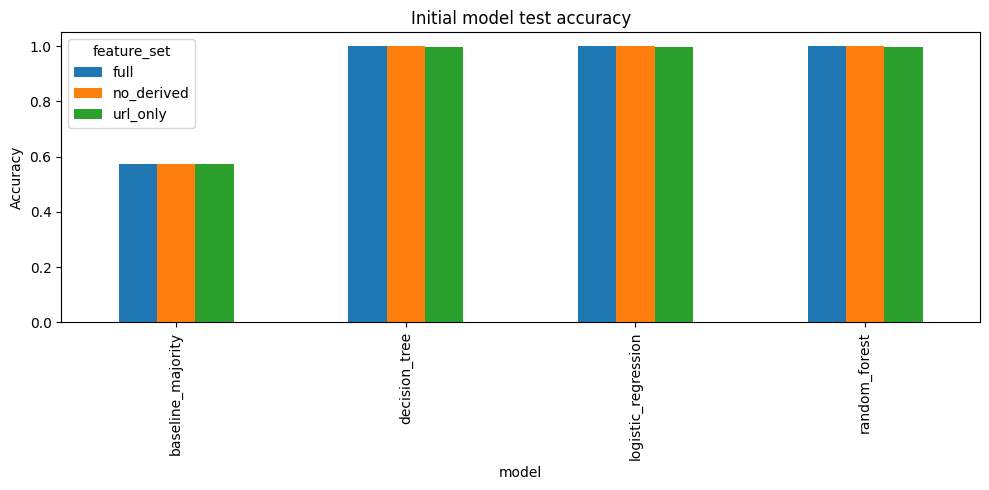

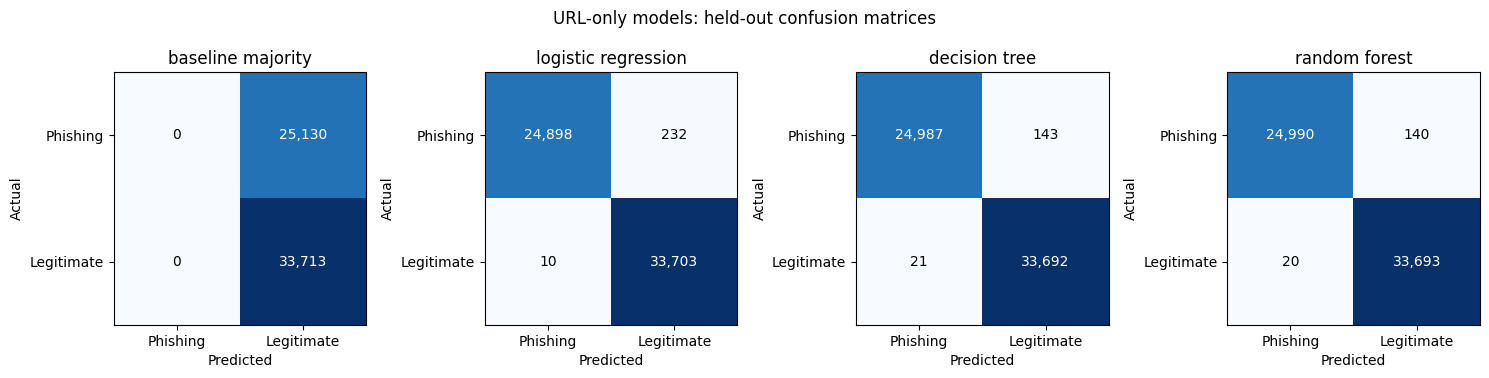

In [10]:
# Validate and display the completed comparison; save accuracy and confusion-matrix plots.
initial_results = show_initial_results()


### Interpret Performance for the Phishing Class

The next summary expresses the confusion-matrix counts as missed phishing URLs and false alarms on legitimate URLs. This makes the consequences of each type of error easier to interpret.


In [11]:
# Inspect the canonical metric files and persist phishing-oriented metrics.
records = review_saved_metrics()
phishing_summary(records)


,feature_set,model,n_features,accuracy,precision,recall,f1,roc_auc
0,full,baseline_majority,50,0.572931,0.000000,0.000000,0.000000,0.500000
1,full,decision_tree,50,1.000000,1.000000,1.000000,1.000000,1.000000
2,full,logistic_regression,50,0.999932,1.000000,0.999841,0.999920,1.000000
3,full,random_forest,50,1.000000,1.000000,1.000000,1.000000,1.000000
4,no_derived,baseline_majority,44,0.572931,0.000000,0.000000,0.000000,0.500000
5,no_derived,decision_tree,44,0.998997,0.998370,0.999284,0.998827,0.999034
6,no_derived,logistic_regression,44,0.999252,0.999522,0.998727,0.999124,0.999994
7,no_derived,random_forest,44,0.999864,0.999920,0.999761,0.999841,1.000000
8,url_only,baseline_majority,18,0.572931,0.000000,0.000000,0.000000,0.500000
9,url_only,decision_tree,18,0.997213,0.999160,0.994310,0.996729,0.996727


Saved precision, recall, and F1 use phishing (0) as positive.
Phishing precision: 99.92%
Phishing recall: 99.44%


,features,model,phishing_precision,phishing_recall,phishing_f1,balanced_accuracy,missed_phishing,false_alerts
0,full,baseline_majority,0.000000,0.000000,0.000000,0.500000,25130,0
1,full,decision_tree,1.000000,1.000000,1.000000,1.000000,0,0
2,full,logistic_regression,1.000000,0.999841,0.999920,0.999920,4,0
3,full,random_forest,1.000000,1.000000,1.000000,1.000000,0,0
4,no_derived,baseline_majority,0.000000,0.000000,0.000000,0.500000,25130,0
5,no_derived,decision_tree,0.998370,0.999284,0.998827,0.999034,18,41
6,no_derived,logistic_regression,0.999522,0.998727,0.999124,0.999185,32,12
7,no_derived,random_forest,0.999920,0.999761,0.999841,0.999851,6,2
8,url_only,baseline_majority,0.000000,0.000000,0.000000,0.500000,25130,0
9,url_only,decision_tree,0.999160,0.994310,0.996729,0.996843,143,21


**Observations:**

- The majority-class baseline achieves 57.29% accuracy but detects no phishing URLs. Its zero phishing recall and F1 demonstrate why accuracy alone is insufficient for this task.
- Among the initial URL-only models, the random forest has the highest F1, approximately 0.9968. It achieves 99.73% accuracy, 99.92% phishing precision, and 99.44% phishing recall, missing 140 phishing URLs and incorrectly flagging 20 legitimate URLs.
- The decision tree and random forest achieve 100% test accuracy with the full feature set. Results also remain very high after the six derived features are removed. These findings warrant closer examination of the dataset and its features; they do not establish equivalent performance on new traffic.
- The saved precision, recall, F1, and cross-validation F1 values use phishing, label 0, as the positive class.


# Part 2: Hyperparameter Tuning, Final Evaluation, and Ethical Considerations

Part 2 builds on the initial comparisons using the same saved row-level split, random seed, and phishing-positive metric convention. It examines whether tuning improves performance, investigates the remaining errors, and considers the limitations of using these results in practice.

The search and evaluation procedures are implemented in `src/tuning.py` and `src/final_eval.py`. By default, the notebook reads their saved results and figures. Model selection uses cross-validation on the training partition; the existing test partition is then reused for comparison with Part 1.


In [12]:
from IPython.display import Image
from src.tuning import PARAM_GRIDS, run_tuning
from src.final_eval import run_final_evaluation, make_final_figures
R, F = C.RESULTS_DIR, C.FIGURES_DIR
pd.set_option("display.float_format", "{:.5f}".format)

# The grid search takes about 40 minutes on 8 cores and the final evaluation
# about 10. Both write everything to results/, so by default these cells read
# the saved outputs. Set a flag to True to recompute from scratch.
RUN_SEARCH = False
RUN_FINAL = False

## 4. Hyperparameter Tuning
### Search Design

This project adapts the assignment's tuning procedure to binary classification. Scikit-learn's `GridSearchCV` evaluates logistic regression, a decision tree, a random forest, and histogram gradient boosting. The search uses phishing-class F1 and five stratified folds with a fixed random seed, using only the URL-only training partition.

The URL-only configuration is the focus because it supports screening without page retrieval and leaves more classification errors to investigate than the other two feature sets. Across the four models, 88 parameter configurations are evaluated over five folds, giving 440 fits. Each grid includes the model's default settings, allowing default and tuned configurations to be compared on identical folds.


In [13]:
# Searched values per model; 88 configurations x 5 folds = 440 fits.
display(pd.DataFrame([{"model": m, "parameter": p, "values": v}
                      for m, g in PARAM_GRIDS.items() for p, v in g.items()]))

,model,parameter,values
0,logistic_regression,clf__C,"[0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]"
1,logistic_regression,clf__class_weight,"[None, balanced]"
2,decision_tree,criterion,"[gini, entropy]"
3,decision_tree,max_depth,"[10, 20, 30, None]"
4,decision_tree,min_samples_leaf,"[1, 5, 20]"
5,random_forest,n_estimators,"[150, 300]"
6,random_forest,max_depth,"[None, 30]"
7,random_forest,min_samples_leaf,"[1, 3]"
8,random_forest,max_features,"[sqrt, 0.5]"
9,hist_gradient_boosting,learning_rate,"[0.05, 0.1, 0.2]"


### Run the Search or Load the Saved Results

With `RUN_SEARCH = False`, the following cell loads the completed search. The table compares each model's default and best mean cross-validation F1, variation across folds, selected parameters, and search time.


,model,n_candidates,default_cv_f1_phishing,best_cv_f1_phishing,best_cv_f1_phishing_sd,cv_f1_gain,best_cv_pr_auc_phishing,best_params,elapsed_seconds
0,logistic_regression,12,0.99542,0.99725,0.00027,0.00183,0.99892,"{""clf__C"": 1000.0, ""clf__class_weight"": ""balan...",25.14946
1,decision_tree,24,0.99667,0.99670,0.00028,0.00003,0.99695,"{""criterion"": ""entropy"", ""max_depth"": 30, ""min...",23.71916
2,random_forest,16,0.99684,0.99694,0.00036,0.00010,0.99876,"{""max_depth"": 30, ""max_features"": 0.5, ""min_sa...",1221.12761
3,hist_gradient_boosting,36,0.99705,0.99747,0.00031,0.00043,0.99850,"{""l2_regularization"": 0.0, ""learning_rate"": 0....",1117.21892


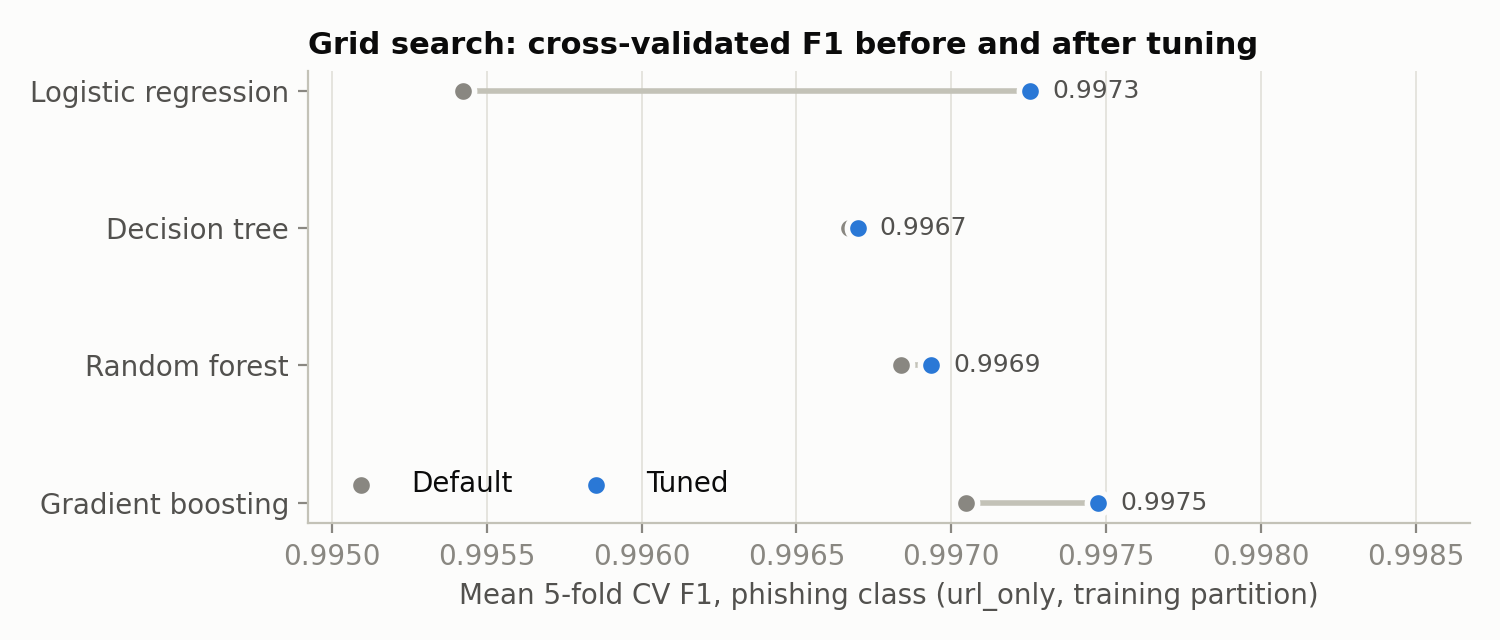

In [14]:
if RUN_SEARCH:
    run_tuning()
summary = pd.read_csv(R / "tuning_summary.csv")
display(summary[["model", "n_candidates", "default_cv_f1_phishing", "best_cv_f1_phishing",
                 "best_cv_f1_phishing_sd", "cv_f1_gain", "best_cv_pr_auc_phishing",
                 "best_params", "elapsed_seconds"]])
display(Image(F / "tuning_cv_f1.png"))

**Observations:**

- Every model's selected configuration has a higher mean cross-validation F1 than its default configuration, although the absolute improvements are small. Because the defaults are included in each grid, this comparison describes the best result found within the tested settings.
- Logistic regression shows the largest increase, from approximately 0.99542 to 0.99725. Its selected configuration uses `C = 1000` and balanced class weights, combining weaker regularization with a change in class weighting.
- The decision tree and random forest improve by approximately 0.00003 and 0.00010, respectively. These gains are smaller than the observed variation across folds, so they should be interpreted cautiously.
- Histogram gradient boosting achieves the highest mean cross-validation F1, approximately 0.99747, and is selected for final evaluation. Its selected settings are a learning rate of 0.2, 600 iterations, 31 maximum leaf nodes, and no L2 regularization.


In [15]:
# Top gradient-boosting candidates. The selected setting is at the grid edge
# (learning_rate 0.2, max_iter 600), so check whether the surface is still rising.
hgb = pd.read_csv(R / "tuning" / "cv_results_hist_gradient_boosting.csv")
display(hgb.sort_values("mean_test_f1_phishing", ascending=False)[
    ["param_learning_rate", "param_max_iter", "param_max_leaf_nodes",
     "param_l2_regularization", "mean_test_f1_phishing", "std_test_f1_phishing"]].head(8))

,param_learning_rate,param_max_iter,param_max_leaf_nodes,param_l2_regularization,mean_test_f1_phishing,std_test_f1_phishing
16,0.20000,600,31,0.00000,0.99747,0.00031
11,0.10000,600,127,0.00000,0.99747,0.00031
5,0.05000,600,127,0.00000,0.99746,0.00033
10,0.10000,600,31,0.00000,0.99746,0.00026
17,0.20000,600,127,0.00000,0.99745,0.00034
9,0.10000,300,127,0.00000,0.99745,0.00031
15,0.20000,300,127,0.00000,0.99744,0.00033
34,0.20000,600,31,1.00000,0.99744,0.00026


**Observations:**

- The eight highest-scoring gradient boosting configurations differ in mean F1 by only about 0.000033, compared with fold standard deviations of approximately 0.0003. Several tested configurations therefore perform similarly.
- The selected learning rate and iteration count are at the upper limits of the search grid. The close scores suggest limited sensitivity among the leading candidates, but the search does not establish whether settings outside the grid would improve performance.


## 5. Final Model Evaluation
### Compare Default and Tuned Models on the Test Partition

The selected settings are fitted on the training partition and evaluated on the same 58,843 test observations used in Part 1. The comparison includes classification metrics and the number of missed phishing URLs and false alarms.

To address the assignment's request for RMSE and MAE, these measures are calculated between the predicted phishing probability and an indicator equal to 1 for phishing and 0 for legitimate URLs. They describe probability prediction error and are reported alongside precision, recall, and F1.


In [16]:
if RUN_FINAL:
    run_final_evaluation()
    make_final_figures()
comparison = pd.read_csv(R / "final_model_comparison.csv")
display(comparison[["model", "config", "accuracy", "precision", "recall", "f1", "mcc",
                    "roc_auc", "pr_auc", "probability_rmse", "probability_mae",
                    "phishing_missed", "legit_flagged"]])

,model,config,accuracy,precision,recall,f1,mcc,roc_auc,pr_auc,probability_rmse,probability_mae,phishing_missed,legit_flagged
0,logistic_regression,default,0.99589,0.99960,0.99077,0.99516,0.99162,0.99813,0.99851,0.06113,0.00877,232,10
1,logistic_regression,tuned,0.99706,0.99924,0.99387,0.99655,0.99400,0.99829,0.99872,0.05089,0.00577,154,19
2,decision_tree,default,0.99721,0.99916,0.99431,0.99673,0.99431,0.99673,0.99732,0.05187,0.00417,143,21
3,decision_tree,tuned,0.99723,0.99920,0.99431,0.99675,0.99434,0.99679,0.99742,0.05147,0.00414,143,20
4,random_forest,default,0.99728,0.99920,0.99443,0.99681,0.99445,0.99811,0.99860,0.04883,0.00477,140,20
5,random_forest,tuned,0.99731,0.99932,0.99439,0.99685,0.99452,0.99805,0.99856,0.04874,0.00454,141,17
6,hist_gradient_boosting,default,0.99745,0.99956,0.99447,0.99701,0.99480,0.99842,0.99878,0.04876,0.00490,139,11
7,hist_gradient_boosting,tuned,0.99782,0.99972,0.99519,0.99745,0.99556,0.99785,0.99845,0.04571,0.00360,121,7


**Observations:**

- Among the eight URL-only configurations compared, tuned histogram gradient boosting achieves the highest test accuracy, precision, recall, F1, and Matthews correlation coefficient. Its accuracy is 99.78%, phishing precision is 99.97%, phishing recall is 99.52%, and F1 is approximately 0.99745.
- The tuned model misses 121 of the 25,130 phishing URLs and incorrectly flags 7 of the 33,713 legitimate URLs. The default gradient boosting model misses 139 and flags 11, so tuning reduces both types of error in this comparison.
- Probability RMSE decreases from approximately 0.0488 to 0.0457, and probability MAE decreases from 0.0049 to 0.0036. However, ROC AUC decreases from approximately 0.9984 to 0.9978. Improving F1 at the classification threshold does not necessarily improve ranking performance across all thresholds.
- The bootstrap results below give a 95% interval of approximately 0.99699 to 0.99784 for the selected model's test F1. This describes uncertainty from resampling the observed test predictions, rather than uncertainty about performance on a different data source.


Final model: hist_gradient_boosting {'l2_regularization': 0.0, 'learning_rate': 0.2, 'max_iter': 600, 'max_leaf_nodes': 31}
Selected by: highest mean CV phishing F1 in tuning_summary.csv (test not used)


,precision,recall,f1
2.5%,0.99952,0.99430,0.99699
97.5%,0.99992,0.99596,0.99784


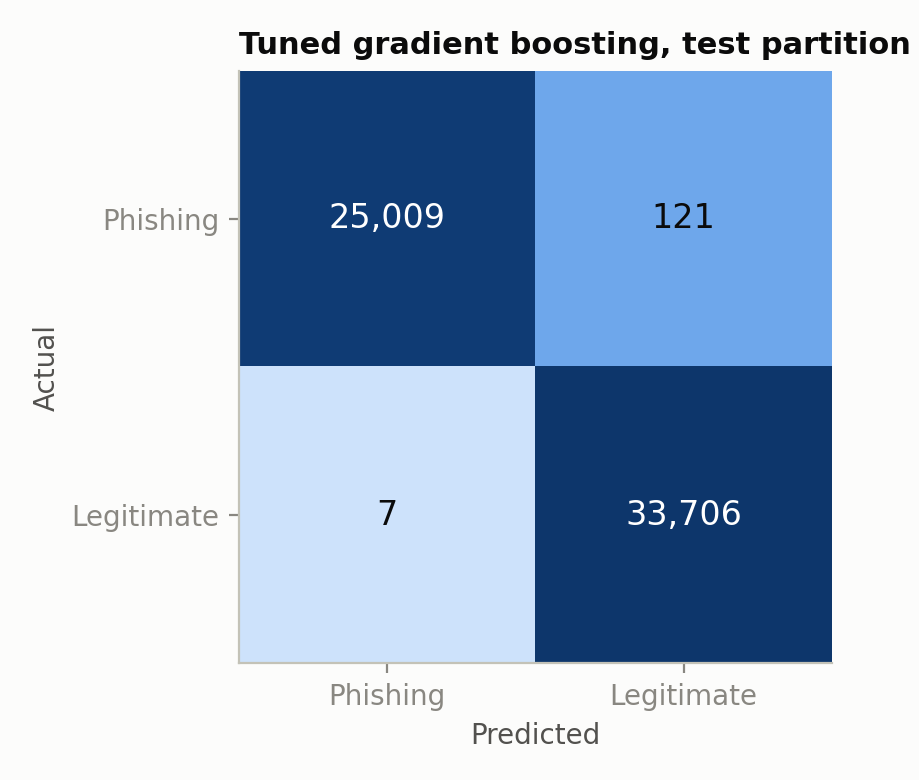

In [17]:
final = json.loads((R / "final_model.json").read_text())
print("Final model:", final["model"], final["params"])
print("Selected by:", final["selected_by"])
display(pd.DataFrame(final["bootstrap_95ci"], index=["2.5%", "97.5%"]))
display(Image(F / "final_confusion_matrix.png"))

### Compare the Selected Settings Across Feature Sets

The configurations selected using URL-only training data are also fitted with the `full` and `no_derived` feature sets. This comparison examines the effect of the available features using the same selected settings; it does not represent a separate tuning search for each feature set.


In [18]:
display(pd.read_csv(R / "final_feature_set_comparison.csv")[
    ["feature_set", "model", "accuracy", "f1", "pr_auc", "phishing_missed", "legit_flagged"]])

,feature_set,model,accuracy,f1,pr_auc,phishing_missed,legit_flagged
0,full,logistic_regression,0.99997,0.99996,1.00000,2,0
1,full,decision_tree,1.00000,1.00000,1.00000,0,0
2,full,random_forest,1.00000,1.00000,1.00000,0,0
3,full,hist_gradient_boosting,1.00000,1.00000,1.00000,0,0
4,no_derived,logistic_regression,0.99956,0.99948,1.00000,11,15
5,no_derived,decision_tree,0.99930,0.99918,0.99859,13,28
6,no_derived,random_forest,0.99968,0.99962,1.00000,8,11
7,no_derived,hist_gradient_boosting,0.99998,0.99998,1.00000,1,0
8,url_only,logistic_regression,0.99706,0.99655,0.99872,154,19
9,url_only,decision_tree,0.99723,0.99675,0.99742,143,20


**Observations:**

- With the full feature set, the tuned decision tree, random forest, and gradient boosting models classify every test observation correctly. Logistic regression misses two phishing URLs and produces no false alarms.
- Performance also remains very high with the `no_derived` feature set. In particular, gradient boosting misses one phishing URL and produces no false alarms. Removing the six derived features therefore does not eliminate the near-perfect results.
- These comparisons suggest that the dataset contains strong class-separating patterns beyond the removed features. The scores alone do not prove that a particular feature leaks the label or that the same patterns will hold in deployment.
- The URL-only results are the most relevant to the proposed screening workflow because they do not require page content. They remain within-dataset estimates and require validation on additional data.


### Examine Decision Thresholds and Error Confidence

Alternative thresholds are selected from out-of-fold predictions on the training partition and then applied to the test partition. The comparison shows how the choice of threshold changes the balance between detecting phishing URLs and flagging legitimate URLs.


,operating_point,threshold,precision,recall,f1,legit_false_alarm_rate,phishing_missed,legit_flagged
0,default,0.50000,0.99972,0.99519,0.99745,0.00021,121,7
1,f1_optimal,0.50001,0.99972,0.99519,0.99745,0.00021,121,7
2,fpr_budget,0.23075,0.99908,0.99550,0.99729,0.00068,113,23


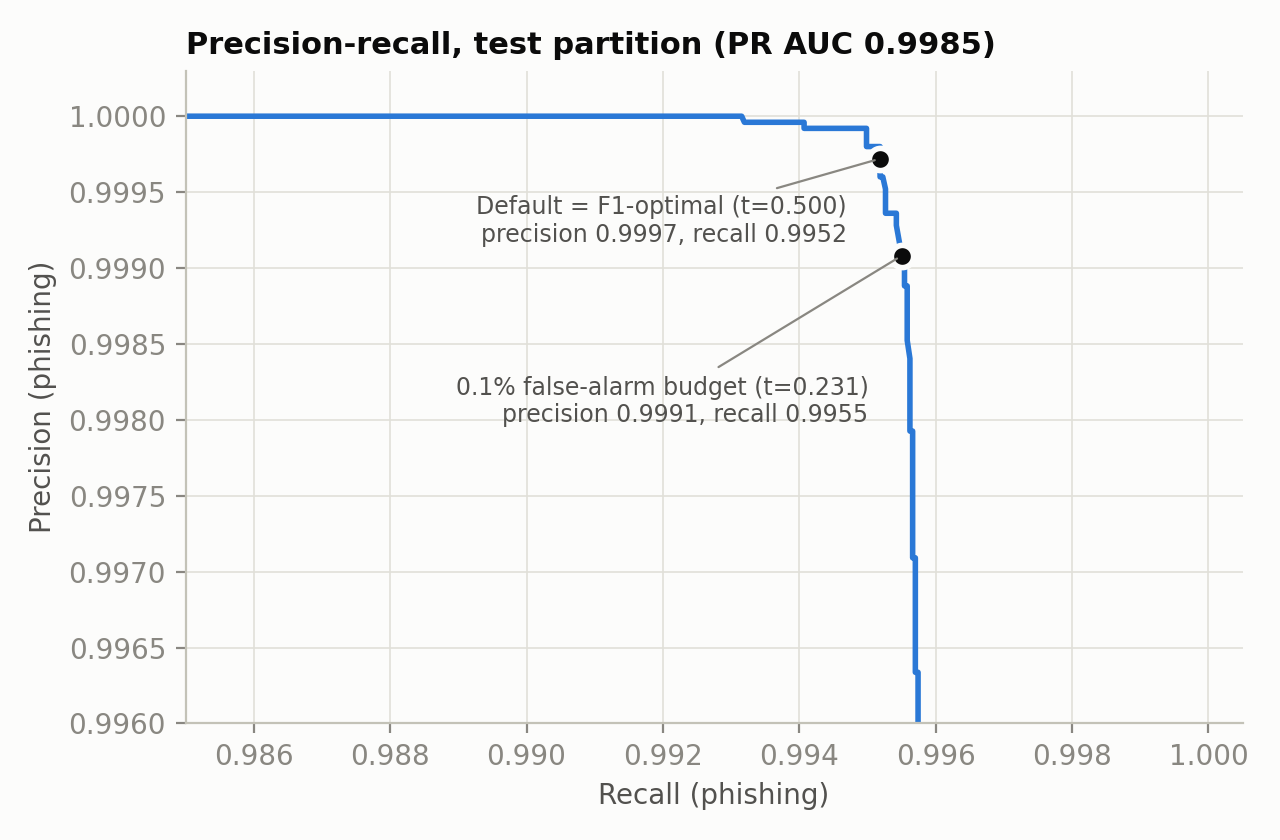

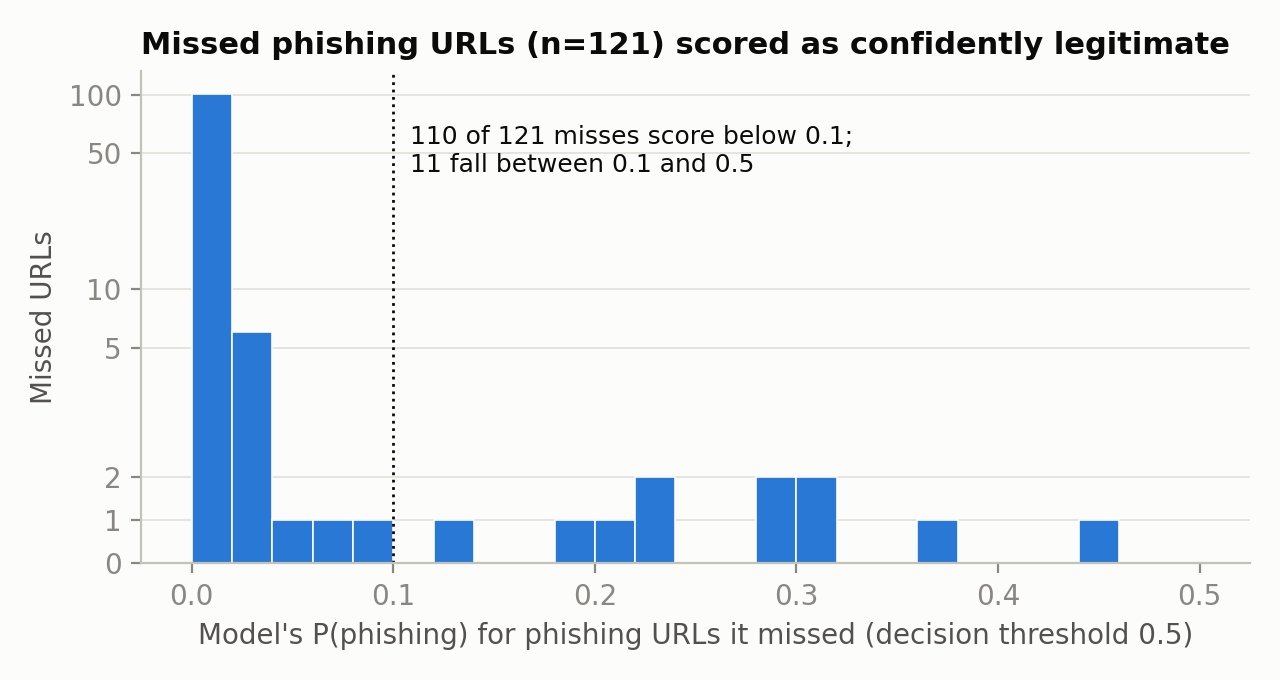

In [19]:
# Thresholds were chosen from out-of-fold training predictions, then applied to test.
display(pd.read_csv(R / "final_thresholds.csv")[
    ["operating_point", "threshold", "precision", "recall", "f1",
     "legit_false_alarm_rate", "phishing_missed", "legit_flagged"]])
display(Image(F / "final_pr_curve.png"))
display(Image(F / "final_error_confidence.png"))

**Observations:**

- The threshold that maximizes F1 on the out-of-fold training predictions is approximately 0.50001. It produces the same test predictions and F1 as the default threshold of 0.5.
- An alternative threshold of approximately 0.231 is selected using a training false-alarm budget of 0.1%. On the test set, it reduces missed phishing URLs from 121 to 113 but increases false alarms from 7 to 23. Its observed test false-alarm rate is approximately 0.068%, and its F1 is slightly lower.
- Of the 121 phishing URLs missed at the default threshold, 110 receive phishing probabilities below 0.1. These errors are far from the decision boundary. Recovering them would require a much lower threshold, whose effect on false alarms would need to be evaluated.
- The tested thresholds illustrate a practical trade-off: detecting more phishing URLs can also increase disruption to legitimate sites.


### Review Misclassified URLs

The following examples and feature summaries compare missed phishing URLs with legitimate URLs that were incorrectly flagged. The reported feature medians describe each outcome group and help identify patterns worth investigating.


In [20]:
errors = pd.read_csv(R / "final_errors.csv")
display(errors[errors.outcome == "phishing_missed"].head(15)[["URL", "TLD", "p_phishing"]])
display(errors[errors.outcome == "legit_flagged"][["URL", "TLD", "p_phishing"]])
display(pd.read_csv(R / "final_error_profile.csv").set_index("feature").loc[
    ["URLLength", "DomainLength", "NoOfSubDomain", "LetterRatioInURL", "IsHTTPS"]])

,URL,TLD,p_phishing
0,https://www.at0.srev.workers.dev,dev,0.00000
1,https://www.uknypxl-rqf-3.ml,ml,0.00000
2,https://www.appleid-find.cloud,cloud,0.00000
3,http://www.ftp.afc.https443.org,org,0.00000
4,https://www.icy.lud.workers.dev,dev,0.00000
5,https://www.serviziofatturazionearuba.com/,com,0.00000
6,https://www.ridm.in,in,0.00000
7,https://www.serviziofatturazionearuba.com,com,0.00000
8,https://www.wsdownloade.cn,cn,0.00000
9,https://www.wsdownloads.cn,cn,0.00000


,URL,TLD,p_phishing
121,https://www.seminole.wateratlas.usf.edu,edu,0.50005
122,https://www.cloudsat.cira.colostate.edu,edu,0.50005
123,https://www.industrydocuments.ucsf.edu,edu,0.60000
124,https://www.secretsdeclassified.af.mil,mil,0.60000
125,https://www.google.blognewschannel.com,com,0.60000
126,https://www.business-services.upenn.edu,edu,0.99951
127,https://www.79798282.net,net,0.99990


,legit_flagged,legit_passed,phishing_caught,phishing_missed
feature,,,,
URLLength,37.00000,26.00000,34.00000,27.00000
DomainLength,30.00000,19.00000,22.00000,20.00000
NoOfSubDomain,2.00000,1.00000,1.00000,1.00000
LetterRatioInURL,0.60500,0.48100,0.57700,0.50000
IsHTTPS,1.00000,1.00000,0.00000,1.00000


**Observations:**

- Some missed phishing URLs contain names resembling familiar brands. The examples suggest that a URL can resemble a legitimate address in its numerical characteristics while still being labeled as phishing.
- The missed phishing group has a median URL length of 27 characters, a median domain length of 20 characters, and a median of one subdomain. These values are close to the corresponding medians of 26, 19, and one among correctly classified legitimate URLs.
- Four of the seven false alarms are `.edu` addresses, and one is a `.mil` address. The flagged legitimate group has longer URLs and more subdomains at the median than the correctly classified legitimate group.
- The current features describe URL structure rather than explicitly measuring brand similarity, domain age, or reputation. Adding such information is a possible direction for further experiments; its benefit has not been tested in this notebook.


### Check Performance on Unseen Recorded Domains

The selected gradient boosting configuration is refitted using a split with no recorded domains shared between training and testing. This provides an additional check on whether the high score persists when domain overlap is removed.


In [21]:
domain = json.loads((R / "final_grouped_split.json").read_text())
print("Domains shared between grouped train and test:", domain["shared_domains_train_test"])
display(pd.DataFrame({"stratified": domain["stratified_test_metrics"],
                      "domain_grouped": domain["test_metrics"]}).loc[
    ["accuracy", "precision", "recall", "f1", "pr_auc", "phishing_missed", "legit_flagged"]])

Domains shared between grouped train and test: 0


,stratified,domain_grouped
accuracy,0.99782,0.99802
precision,0.99972,0.99955
recall,0.99519,0.99577
f1,0.99745,0.99766
pr_auc,0.99845,0.99859
phishing_missed,121.00000,105.00000
legit_flagged,7.00000,11.00000


**Observations:**

- The grouped split has zero recorded domains in common between training and testing. On its 58,464 test observations, the model achieves F1 of approximately 0.99766, with 105 missed phishing URLs and 11 false alarms.
- This score is close to the row-level split's F1 of approximately 0.99745. Strong performance therefore persists when shared recorded domains are removed in this additional experiment.
- The partitions contain different observations, and the model settings were originally selected using the row-level split. This is a useful diagnostic within the same dataset, but it does not establish performance on future traffic or independently collected data.


## 6. Ethical Considerations
### Examine Who Is Affected by False Alarms

The dataset does not contain demographic attributes, so this analysis cannot assess demographic fairness. Instead, it compares errors across top-level domains and the recorded `IsHTTPS` feature to examine whether some categories of legitimate websites experience more false alarms. These comparisons describe patterns in the test data; they do not establish the causes of those differences.


,TLD,n,n_legit,n_phishing,share_phishing,legit_false_alarm_rate,phishing_miss_rate
0,com,28180,17301,10879,0.38605,0.00006,0.00616
1,org,4644,4094,550,0.11843,0.00000,0.00545
2,net,1693,951,742,0.43828,0.00105,0.00943
3,uk,1604,1517,87,0.05424,0.00000,NaN
4,app,1578,36,1542,0.97719,NaN,0.00000
5,co,1387,115,1272,0.91709,NaN,0.00079
6,io,1049,112,937,0.89323,NaN,0.00000
7,de,1004,842,162,0.16135,0.00000,NaN
8,ru,1000,223,777,0.77700,0.00000,0.00515
9,au,712,613,99,0.13904,0.00000,NaN


,IsHTTPS,n,n_legit,n_phishing,share_phishing,legit_false_alarm_rate,phishing_miss_rate
0,1,46023,33713,12310,0.26747,0.00021,0.00983
1,0,12820,0,12820,1.00000,NaN,0.00000


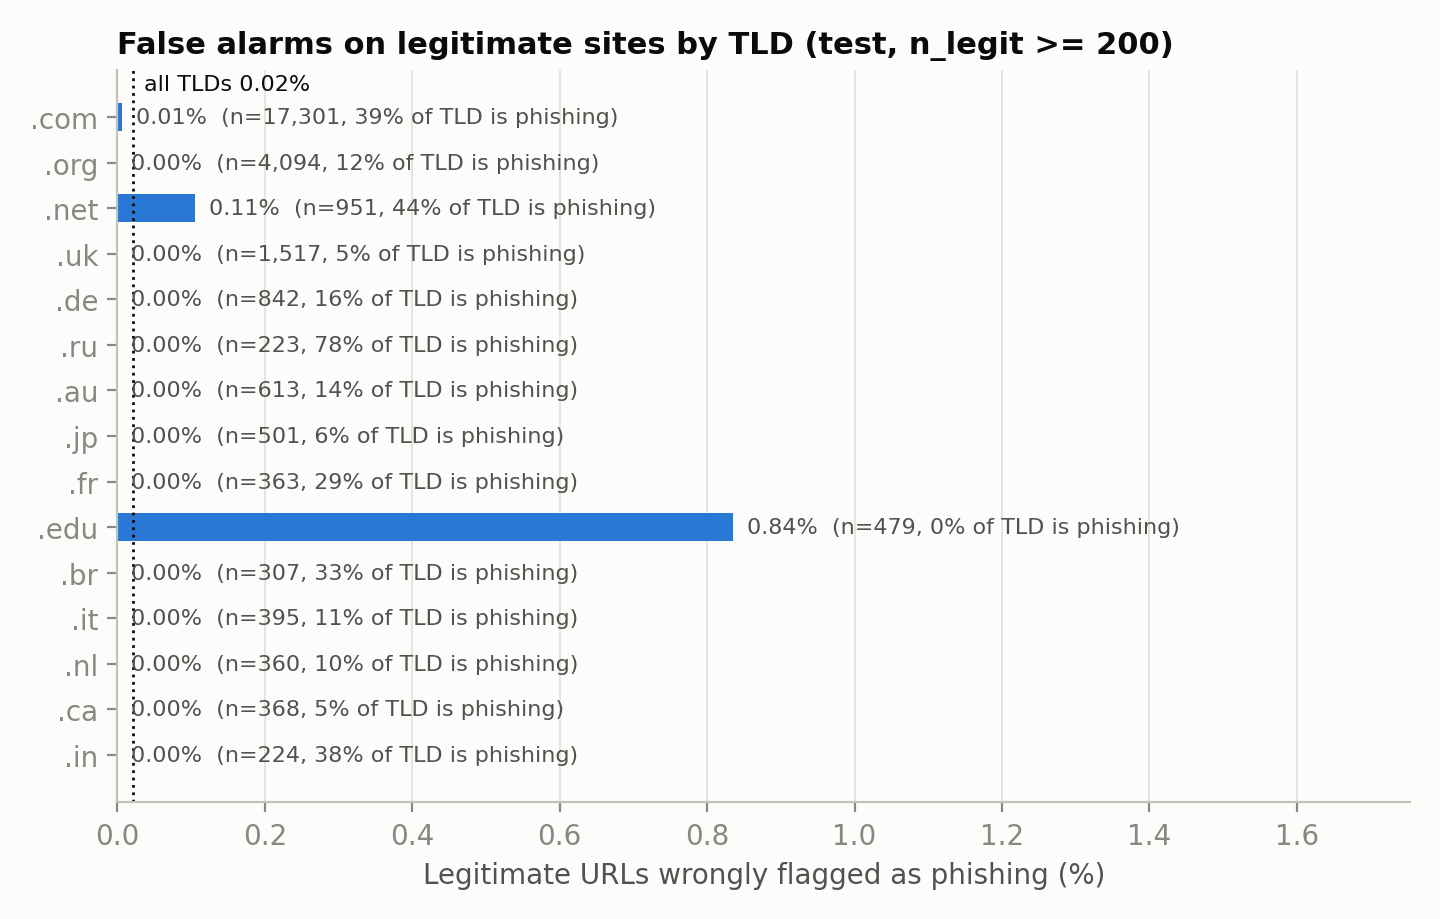

In [22]:
tld = pd.read_csv(R / "final_group_error_rates_tld.csv")
display(tld.head(15))
display(pd.read_csv(R / "final_group_error_rates_https.csv"))
display(Image(F / "final_false_alarms_by_tld.png"))

**Observations:**

- Four of the 479 legitimate `.edu` URLs are incorrectly flagged, giving a false-alarm rate of approximately 0.84%. For `.com`, one of 17,301 legitimate URLs is flagged, approximately 0.0058%. This difference deserves investigation, although the small number of errors limits the precision of the comparison.
- False-alarm rates for `.app`, `.io`, `.co`, `.dev`, and `.top` are withheld because each has fewer than the analysis's minimum of 200 legitimate test observations. Their legitimate counts are 36, 112, 115, 7, and one, respectively. A missing rate indicates limited evidence, not an absence of risk.
- All 12,820 test observations recorded as `IsHTTPS = 0` are labeled as phishing. There are no legitimate observations in that group, so its legitimate false-alarm rate cannot be measured. This strong association raises concerns about how well the model would handle legitimate URLs with the same feature value.
- Broader evaluation data are needed before drawing firm conclusions about which kinds of legitimate sites would be affected in practice.


### Explain the Model's Main Predictive Features

Permutation importance measures the decrease in F1 when a feature's values are shuffled in the evaluation sample. Larger decreases indicate that the fitted model relies more strongly on that feature in this analysis. This is a summary of model behavior, rather than a causal explanation of why a URL is phishing.


,feature,f1_drop_mean,f1_drop_sd
0,URLLength,0.27216,0.00168
1,LetterRatioInURL,0.25488,0.00200
2,DomainLength,0.22109,0.00231
3,IsHTTPS,0.21966,0.00222
4,NoOfLettersInURL,0.11851,0.00105
5,NoOfOtherSpecialCharsInURL,0.11781,0.00137
6,SpacialCharRatioInURL,0.06165,0.00227
7,NoOfDegitsInURL,0.05591,0.00128
8,DegitRatioInURL,0.04529,0.00062
9,NoOfSubDomain,0.03534,0.00115


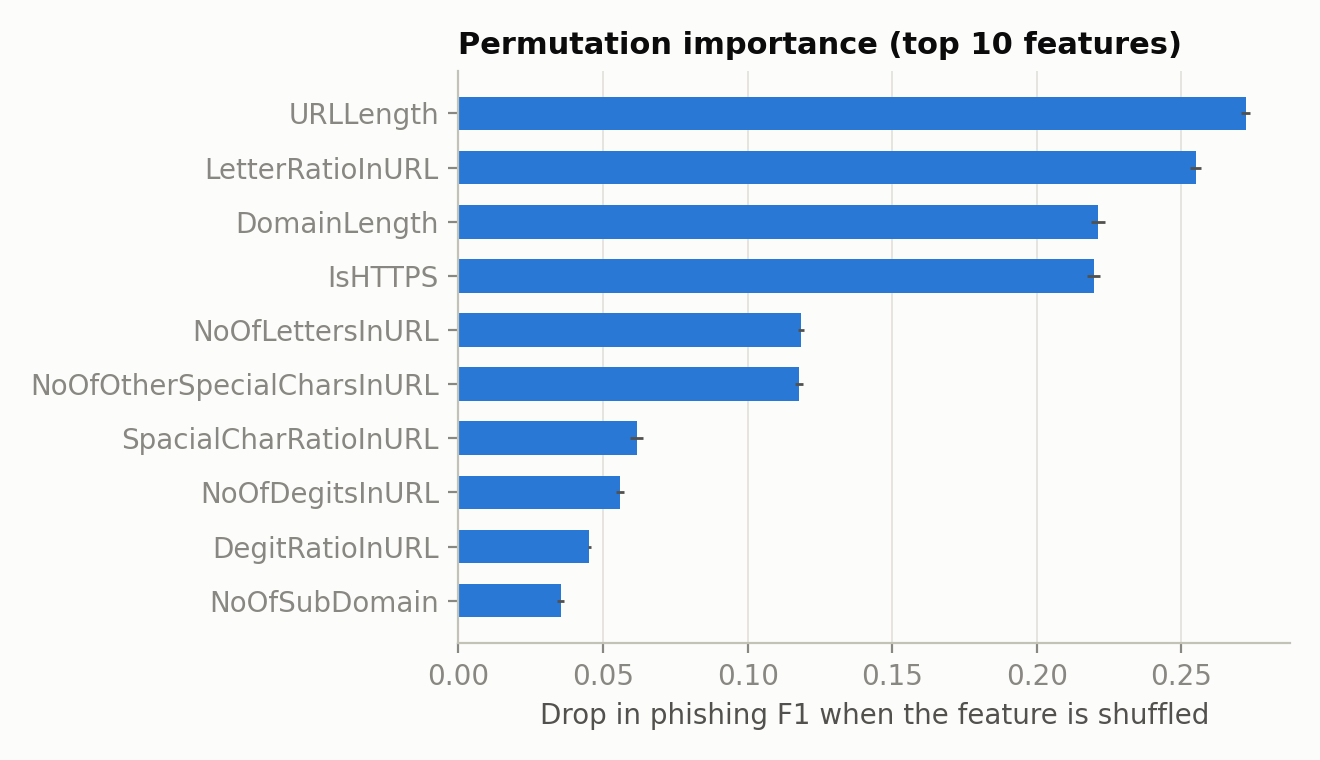

In [23]:
display(pd.read_csv(R / "final_permutation_importance.csv").head(10))
display(Image(F / "final_permutation_importance.png"))

**Observations:**

- Shuffling `URLLength`, `LetterRatioInURL`, `DomainLength`, and `IsHTTPS` produces the four largest average decreases in F1: approximately 0.272, 0.255, 0.221, and 0.220, respectively. The fitted model relies strongly on these structural characteristics.
- These rankings help explain the model's overall behavior, but they do not provide a complete explanation for any individual prediction. Because some features are related, their importance values should not be interpreted as independent contributions that can simply be added together.
- The importance of `IsHTTPS`, together with the lack of legitimate test examples recorded as non-HTTPS, motivates collecting more representative examples and testing the effect of removing that feature.
- Possible safeguards include monitoring false alarms by website category, providing a process for reviewing disputed alerts, and limiting the collection and retention of raw URLs because they can reveal browsing activity. These are proposed deployment measures, not features implemented in this notebook.


## 7. Real-World Application
### Examine Precision at Different Phishing Rates

Phishing URLs make up approximately 42.7% of the test set. The following calculation considers how precision would change at lower phishing rates while holding the measured recall and legitimate false-alarm rate constant. The 1% and 0.1% rates are illustrative scenarios, not measured rates from a deployment environment.


In [24]:
m = final["test_metrics"]
recall, far = m["recall"], m["legit_false_alarm_rate"]
test_prevalence = (m["phishing_caught"] + m["phishing_missed"]) / m["n_test"]
rows = []
for prevalence in [test_prevalence, 0.01, 0.001]:
    caught = recall * prevalence * 1_000_000
    false_alarms = far * (1 - prevalence) * 1_000_000
    rows.append({"phishing_prevalence": prevalence,
                 "phishing_caught_per_million": round(caught),
                 "false_alarms_per_million": round(false_alarms),
                 "precision": caught / (caught + false_alarms)})
display(pd.DataFrame(rows))

,phishing_prevalence,phishing_caught_per_million,false_alarms_per_million,precision
0,0.42707,425012,119,0.99972
1,0.01000,9952,206,0.97976
2,0.00100,995,207,0.82752


**Observations:**

- Under the stated assumptions, precision is approximately 97.98% when phishing accounts for 1% of traffic and 82.75% when it accounts for 0.1%, compared with 99.97% at the test-set prevalence.
- At the 0.1% scenario, one million URLs would produce approximately 995 correctly detected phishing URLs and 207 false alarms. About one in six alerts would therefore concern a legitimate URL, despite the model's low measured false-alarm rate.
- These calculations show why evaluation should reflect the expected traffic mix. They are not deployment forecasts, since recall and false-alarm rates may also change on new data.
- A possible application is an initial URL screening stage in an email gateway or browser security tool, supported by reputation checks, page analysis, or review before high-impact blocking decisions. Escalating only uncertain predictions would not address the confidently missed phishing URLs identified earlier.
- Before deployment, further work should include validation on newer data, evaluation of additional features, selection of an error trade-off appropriate to the application, and monitoring of false alarms and changes in the data.


## 8. Final Thoughts

- **Phishing detection requires more than accuracy.** The majority-class baseline achieved 57.29% accuracy but detected no phishing URLs. Precision, recall, F1, and error counts provided a more useful assessment of the models.
- **Tuning produced modest improvements.** Histogram gradient boosting achieved the highest mean cross-validation F1. Tuning increased its test F1 from approximately 0.99701 to 0.99745, reduced missed phishing URLs from 139 to 121, and reduced false alarms from 11 to 7.
- **The domain-grouped evaluation provided an additional check.** The model achieved F1 of approximately 0.99766 when no recorded domains were shared between training and testing. This supports further evaluation, but it does not establish performance on future traffic or independently collected data.
- **The remaining errors deserve attention.** Of the 121 missed phishing URLs, 110 received phishing probabilities below 0.1. Their numerical URL characteristics resembled those of legitimate URLs, motivating experiments with additional information such as brand similarity and domain reputation.
- **Threshold changes involve a trade-off.** The tested lower threshold detected eight additional phishing URLs but introduced 16 additional false alarms. The operating threshold should therefore reflect the consequences of both types of error.
- **The dataset limits the conclusions.** Near-perfect results persisted after the derived features were removed. False alarms differed across top-level domains, some groups had few legitimate examples, and no legitimate test observations were recorded as non-HTTPS.
- **Precision depends on the traffic mix.** At an illustrative phishing rate of 0.1%, precision fell to approximately 82.75% when the measured recall and false-alarm rate were held constant. This calculation shows why the dataset's high precision should not be assumed to hold in deployment.
- **The saved experiment supports further work.** The code, split assignments, metrics, and figures provide a basis for reproducing the analysis and evaluating additional features and more representative data.


## 9. Conclusion

This project developed and evaluated a phishing URL classification workflow covering data preparation, initial model comparisons, hyperparameter tuning, and detailed error analysis. The tuned histogram gradient boosting model performed strongly with the 18 URL-only features, achieving 99.78% test accuracy and a phishing F1 of approximately 0.99745. Its results demonstrate the potential of URL-based screening within the available dataset.

The analysis also identified limitations that high aggregate scores alone would conceal, including confidently missed phishing URLs, differences in false alarms across website categories, and gaps in the evaluation data. Before practical deployment, the model should be assessed on independently collected and more recent data, additional features should be tested, and alert review and monitoring procedures should be established. The project's contribution is a reproducible evaluation of both the model's performance and the evidence still needed for reliable use.


### Data Source and Result Provenance

- **Dataset:** Prasad and Chandra, [PhiUSIIL Phishing URL Dataset, UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/967/phiusiil+phishing+url+dataset).
- **Initial experiments:** Sections 1-3 display the preprocessing diagnostics and saved model results produced by the shared project modules, including `src/initial_models.py`.
- **Tuning and final evaluation:** Sections 4-9 use outputs from `src/tuning.py` and `src/final_eval.py`, including the tuning comparisons, test metrics, threshold analysis, error summaries, and grouped evaluation saved in `results/`.
- **Interpretation:** Numerical observations refer to the displayed results and saved artifacts. Proposed features, safeguards, and deployment steps are recommendations for future work and have not been evaluated here.
